# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

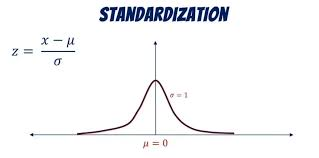


In [ ]:
# Step 1: Load and Standardize the Data using NumPy only
import numpy as np

# Load CSV using numpy
data = np.genfromtxt('/content/African_Countries_All_Real.csv', delimiter=',', names=True, dtype=None, encoding=None)

# Encode countries numerically
Country_codes = np.arange(len(data))

# Extract numeric columns
Year = data['Year'].astype(float)
Population = data['Population'].astype(float)
GDP = data['GDP'].astype(float)
Unemployment = data['Unemployment'].astype(float)
Inflation = data['Inflation'].astype(float)
Literacy_Rate = data['Literacy_Rate'].astype(float)
Life_Expectancy = data['Life_Expectancy'].astype(float)
Internet_Usage = data['Internet_Usage'].astype(float)

# Fill missing values
GDP = np.where(np.isnan(GDP), np.nanmean(GDP), GDP)
Internet_Usage = np.where(np.isnan(Internet_Usage), np.nanmean(Internet_Usage), Internet_Usage)

# Combine numeric columns into array
X = np.column_stack((Country_codes, Year, Population, GDP, Unemployment, Inflation, Literacy_Rate, Life_Expectancy, Internet_Usage))

# Standardize data
X_scaled = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [ ]:
# Step 3: Calculate Covariance Matrix
cov_matrix = np.cov(X_scaled, rowvar=False)

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Print sorted eigenvalues and eigenvectors
print("Sorted Eigenvalues:")
print(eigenvalues)
print("\nSorted Eigenvectors:")
print(eigenvectors)

Sorted Eigenvalues:
[1.65043314 1.49861787 1.40040218 1.06428983 0.97101745 0.81019556
 0.7000412  0.59776654 0.47704756]

Sorted Eigenvectors:
[[ 0.1972225  -0.59279232 -0.03540698  0.12307446 -0.16040432  0.21135462
   0.66140174 -0.12882805  0.26239345]
 [-0.38948462 -0.10567041  0.41105968 -0.37130279 -0.36336892 -0.08094993
   0.13149103  0.60490239  0.09226599]
 [ 0.61828863  0.0606093   0.20966024  0.09163463 -0.02701502  0.25664471
   0.08008656  0.40958172 -0.56650155]
 [-0.34049138  0.39670665 -0.39289575  0.0920995   0.03543544 -0.1357841
   0.63407818  0.09453029 -0.36490543]
 [ 0.12018546 -0.29106642 -0.43088609 -0.40548192 -0.52654186 -0.2589533
  -0.17619213 -0.18487724 -0.37580711]
 [ 0.26252386  0.03058563  0.27218387 -0.59313887  0.46701959 -0.4031409
   0.28370439 -0.20674194 -0.01968922]
 [-0.45000284 -0.34671669  0.10824189 -0.20490362  0.32904602  0.50971066
  -0.07201818 -0.19803833 -0.45945744]
 [-0.15395374 -0.38043543  0.30129519  0.51892327  0.0761438  -0.602

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)
num_components = np.argmax(cumulative_variance >= 0.90) + 1
X_pca = np.dot(X_scaled, eigenvectors[:, :num_components])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output Reduced Data
print('Reduced Data Shape:', X_pca.shape)
print(X_pca[:5])

Reduced Data Shape: (54, 8)
[[-2.07277807  1.94613311  1.21770633  0.50433155 -1.01601914  0.71334097
  -0.39971278  0.56508457]
 [-2.95902825  0.93284978  0.71224769  0.95143311  0.45655964  0.49347901
  -0.97205105 -1.30813016]
 [ 1.64428145  1.58242533  0.49916048 -1.00072088 -0.74465622 -0.16339663
  -1.04576366  0.80870725]
 [-0.22525934  1.75693494  0.75439498 -1.9067588  -0.89954275 -0.48461776
  -0.06716257  0.37969099]
 [ 0.04051174  1.14678679  1.40837518  1.07317552  1.27344609 -1.75422407
  -0.60750764 -0.64665818]]


### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

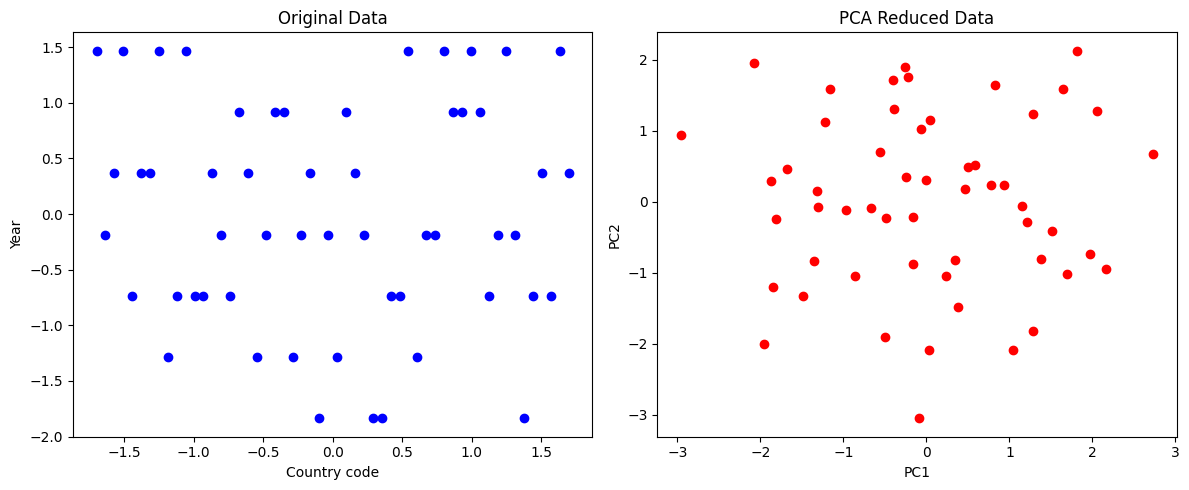

In [ ]:
# Step 8: Visualize Before and After PCA
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

# Original data
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c='blue')
plt.xlabel('Country code')
plt.ylabel('Year')
plt.title('Original Data')

# PCA reduced data
plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c='red')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Reduced Data')
plt.tight_layout()
plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


**1. Interpret the visual (before/after PCA):**

In the first plot, the data seems to be scattered and complex.The first plot displays the original data, which appears to be scattered and difficult to interpret. The second plot displays the data after PCA and rotated along new axes (PC1 and PC2) that contain most of the important patterns. This will make the trends and clusters more visible than the original plot.

**2. The number of principal components we selected was chosen because of the following reasons:**

We selected sufficient components so that at least 90% of the total information in the data is captured. This will decrease the number of features whilst retaining most patterns. Fewer components make analysis easier and adding too many won't change data very much. This balance helps to study the primary trends.

**3. What information is lost after PCA:**

PCA fuses the original features into new features, so some information regarding particular features, say GDP or Literacy Rate are lost. Explicit values of individual features are not apparent, but overall trends and patterns remain. This tradeoff is useful to make the data easier to read, but it may result in the loss of some information.

In [ ]:


# Performance Benchmark for Large Dataset
import numpy as np
import time

# Generate a large synthetic dataset (100,000 rows × 9 features)
np.random.seed(42)
rows = 100_000
features = 9
X_large = np.random.rand(rows, features)

# Standardize
start_time = time.time()
X_scaled_large = (X_large - np.mean(X_large, axis=0)) / np.std(X_large, axis=0)
end_time = time.time()
print(f"Standardization time: {end_time - start_time:.2f} seconds")

# Covariance matrix
start_time = time.time()
cov_matrix_large = np.cov(X_scaled_large, rowvar=False)
end_time = time.time()
print(f"Covariance computation time: {end_time - start_time:.2f} seconds")

# Eigendecomposition
start_time = time.time()
eigenvalues_large, eigenvectors_large = np.linalg.eig(cov_matrix_large)
end_time = time.time()
print(f"Eigendecomposition time: {end_time - start_time:.2f} seconds")

# Sort eigenvectors and project data onto first 5 PCs
sorted_indices = np.argsort(eigenvalues_large)[::-1]
eigenvectors_large = eigenvectors_large[:, sorted_indices]
start_time = time.time()
X_pca_large = np.dot(X_scaled_large, eigenvectors_large[:, :5])
end_time = time.time()
print(f"Projection time: {end_time - start_time:.2f} seconds")


Standardization time: 0.02 seconds
Covariance computation time: 0.01 seconds
Eigendecomposition time: 0.00 seconds
Projection time: 0.00 seconds
